# Assignment 05 - Diabetes: Benchmark CNN, VGG, ResNet và DenseNet

Notebook này dùng dataset Diabetes đã có sẵn để so sánh bốn kiến trúc compact: Basic CNN, Compact VGG, Compact ResNet và Compact DenseNet. Vì dữ liệu là bảng, các mô hình dùng Conv1D trên vector đặc trưng đã chuẩn hóa; đây là minh họa kiến trúc CNN, không hàm ý rằng thứ tự đặc trưng có quan hệ lân cận tự nhiên như pixel ảnh.

## 1. Mục tiêu và quy trình

Quy trình gồm: loại dòng trùng, split stratified `70%/15%/15%`, fit preprocessing chỉ trên train, reshape vector 15 đặc trưng thành `(15, 1)`, huấn luyện bốn mô hình với cùng optimizer/callback, chọn threshold tối ưu F1 trên validation và đánh giá test set một lần cuối.

## 2. Cấu hình thư viện và seed

Cell này cố định seed để các mô hình dùng cùng điều kiện khởi tạo/split trong phạm vi có thể kiểm soát của TensorFlow.

In [1]:
import os
os.environ["PYTHONHASHSEED"] = "42"

from pathlib import Path
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
    print("TensorFlow deterministic ops: enabled")
except Exception as exc:
    print("TensorFlow deterministic ops unavailable:", exc)

pd.set_option("display.max_columns", 80)
pd.options.display.float_format = "{:.4f}".format
sns.set_theme(style="whitegrid")
print("TensorFlow:", tf.__version__)

TensorFlow deterministic ops: enabled
TensorFlow: 2.21.0


## 3. CNN như hàm hợp

CNN có thể viết dưới dạng hàm hợp:

`x -> Convolution -> BatchNorm -> ReLU -> Pooling -> Classifier -> Probability`.

Với dữ liệu bảng đã reshape thành chuỗi đặc trưng, `Conv1D` trượt kernel trên trục đặc trưng. Cách làm này giúp nhìn thấy cùng cấu trúc hàm của CNN, nhưng quan hệ lân cận giữa cột dữ liệu bảng không tự nhiên như ảnh.

In [2]:
def conv1d_valid(x, kernel, bias=0.0):
    x = np.asarray(x, dtype="float32")
    kernel = np.asarray(kernel, dtype="float32")
    return np.array([np.sum(x[i : i + len(kernel)] * kernel) + bias for i in range(len(x) - len(kernel) + 1)])


def max_pool1d_valid(x, pool_size=2):
    usable = (len(x) // pool_size) * pool_size
    return x[:usable].reshape(-1, pool_size).max(axis=1)


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


x_demo = np.linspace(-1, 1, 15).astype("float32")
kernel_demo = np.array([0.25, -0.50, 0.25], dtype="float32")
conv_demo = conv1d_valid(x_demo, kernel_demo)
bn_demo = (conv_demo - conv_demo.mean()) / (conv_demo.std() + 1e-6)
relu_demo = np.maximum(bn_demo, 0)
pool_demo = max_pool1d_valid(relu_demo, pool_size=2)
flat_demo = pool_demo.reshape(1, -1)
weights_demo = np.linspace(-0.3, 0.3, flat_demo.shape[1]).reshape(-1, 1)
prob_demo = sigmoid(flat_demo @ weights_demo)

shape_flow = pd.DataFrame(
    [
        ("Input x", x_demo.shape),
        ("Convolution", conv_demo.shape),
        ("BatchNorm", bn_demo.shape),
        ("ReLU", relu_demo.shape),
        ("Pooling", pool_demo.shape),
        ("Flatten", flat_demo.shape),
        ("Probability", prob_demo.shape),
    ],
    columns=["Bước", "Shape"],
)
display(shape_flow)
print("Xác suất demo:", float(prob_demo.ravel()[0]))

,Bước,Shape
0,Input x,"(15,)"
1,Convolution,"(13,)"
2,BatchNorm,"(13,)"
3,ReLU,"(13,)"
4,Pooling,"(6,)"
5,Flatten,"(1, 6)"
6,Probability,"(1, 1)"


Xác suất demo: 0.5002906939804853


## 3. Ba hướng phát triển từ CNN

Các kiến trúc dưới đây đều có thể nhìn như những cách khác nhau để thiết kế hàm hợp:

- **VGG**: tăng độ sâu bằng cách chồng nhiều convolution `3x3`: `H(x)=Conv3x3(ReLU(BN(Conv3x3(x))))`.
- **ResNet**: học phần dư thay vì học toàn bộ ánh xạ: `y = ReLU(F(x) + P(x))`, trong đó `P(x)` là phép chiếu `1x1` khi cần đổi số kênh hoặc stride.
- **DenseNet**: mỗi lớp nhận tất cả đặc trưng trước đó: `x_l = H_l([x_0, x_1, ..., x_{l-1}])`.

Trong notebook này, các phiên bản đều là compact và huấn luyện từ đầu, không dùng pretrained.

## 4. Hiện thực kiến trúc Conv1D

Bốn hàm `build_basic_cnn`, `build_vgg_compact`, `build_resnet_compact` và `build_densenet_compact` được viết trực tiếp trong notebook. Basic CNN dùng các block Conv-BN-ReLU, VGG chồng nhiều convolution `3x3`, ResNet cộng shortcut, DenseNet nối kênh đặc trưng.

In [3]:
def conv1d_bn_relu(x, filters, kernel_size=3, strides=1, name="conv"):
    x = layers.Conv1D(
        filters,
        kernel_size,
        strides=strides,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name}_conv",
    )(x)
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    return layers.Activation("relu", name=f"{name}_relu")(x)


def build_basic_cnn(input_shape=(15, 1)):
    inputs = layers.Input(shape=input_shape)
    x = inputs
    for stage, filters in enumerate([32, 64, 128], start=1):
        x = conv1d_bn_relu(x, filters, name=f"basic_s{stage}")
        if stage < 3:
            x = layers.MaxPooling1D(pool_size=2, padding="same", name=f"basic_s{stage}_pool")(x)
        x = layers.Dropout(0.15, name=f"basic_s{stage}_dropout")(x)
    x = layers.GlobalAveragePooling1D(name="gap")(x)
    x = layers.Dense(64, activation="relu", kernel_initializer="he_normal", name="head_dense")(x)
    x = layers.Dropout(0.25, name="head_dropout")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="prob_diabetes")(x)
    return models.Model(inputs, outputs, name="basic_cnn")


def build_vgg_compact(input_shape=(15, 1)):
    inputs = layers.Input(shape=input_shape)
    x = inputs
    for stage, (num_convs, filters) in enumerate(zip([2, 2, 3], [32, 64, 128]), start=1):
        for block in range(1, num_convs + 1):
            x = conv1d_bn_relu(x, filters, name=f"vgg_s{stage}_b{block}")
        x = layers.MaxPooling1D(pool_size=2, padding="same", name=f"vgg_s{stage}_pool")(x)
        x = layers.Dropout(0.15, name=f"vgg_s{stage}_dropout")(x)
    x = layers.GlobalAveragePooling1D(name="gap")(x)
    x = layers.Dense(96, activation="relu", kernel_initializer="he_normal", name="head_dense")(x)
    x = layers.Dropout(0.30, name="head_dropout")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="prob_diabetes")(x)
    return models.Model(inputs, outputs, name="compact_vgg")


def residual_block_1d(x, filters, stride=1, name="res"):
    shortcut = x
    x = layers.Conv1D(
        filters,
        3,
        strides=stride,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name}_conv1",
    )(x)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = layers.Activation("relu", name=f"{name}_relu1")(x)
    x = layers.Conv1D(
        filters,
        3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name}_conv2",
    )(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)
    if stride != 1 or int(shortcut.shape[-1]) != filters:
        shortcut = layers.Conv1D(
            filters,
            1,
            strides=stride,
            padding="same",
            use_bias=False,
            kernel_initializer="he_normal",
            name=f"{name}_proj_conv",
        )(shortcut)
        shortcut = layers.BatchNormalization(name=f"{name}_proj_bn")(shortcut)
    x = layers.Add(name=f"{name}_add")([x, shortcut])
    return layers.Activation("relu", name=f"{name}_out")(x)


def build_resnet_compact(input_shape=(15, 1)):
    inputs = layers.Input(shape=input_shape)
    x = conv1d_bn_relu(inputs, 32, name="stem")
    for stage, filters in enumerate([32, 64, 128], start=1):
        stride = 1 if stage == 1 else 2
        x = residual_block_1d(x, filters, stride=stride, name=f"res_s{stage}_b1")
        x = residual_block_1d(x, filters, stride=1, name=f"res_s{stage}_b2")
    x = layers.GlobalAveragePooling1D(name="gap")(x)
    x = layers.Dropout(0.25, name="head_dropout")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="prob_diabetes")(x)
    return models.Model(inputs, outputs, name="compact_resnet")


def dense_layer_1d(x, growth_rate=16, name="dense_layer"):
    y = layers.BatchNormalization(name=f"{name}_bn1")(x)
    y = layers.Activation("relu", name=f"{name}_relu1")(y)
    y = layers.Conv1D(
        growth_rate * 4,
        1,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name}_conv1",
    )(y)
    y = layers.BatchNormalization(name=f"{name}_bn2")(y)
    y = layers.Activation("relu", name=f"{name}_relu2")(y)
    y = layers.Conv1D(
        growth_rate,
        3,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name}_conv2",
    )(y)
    return layers.Concatenate(axis=-1, name=f"{name}_concat")([x, y])


def dense_block_1d(x, num_layers, growth_rate=16, name="dense_block"):
    for layer_idx in range(1, num_layers + 1):
        x = dense_layer_1d(x, growth_rate=growth_rate, name=f"{name}_l{layer_idx}")
    return x


def transition_block_1d(x, compression=0.5, name="transition"):
    filters = max(8, int(int(x.shape[-1]) * compression))
    x = layers.BatchNormalization(name=f"{name}_bn")(x)
    x = layers.Activation("relu", name=f"{name}_relu")(x)
    x = layers.Conv1D(
        filters,
        1,
        padding="same",
        use_bias=False,
        kernel_initializer="he_normal",
        name=f"{name}_conv",
    )(x)
    return layers.AveragePooling1D(pool_size=2, padding="same", name=f"{name}_pool")(x)


def build_densenet_compact(input_shape=(15, 1)):
    inputs = layers.Input(shape=input_shape)
    x = conv1d_bn_relu(inputs, 32, name="stem")
    for block_idx, num_layers in enumerate([3, 4, 4], start=1):
        x = dense_block_1d(x, num_layers, growth_rate=16, name=f"dense_b{block_idx}")
        if block_idx < 3:
            x = transition_block_1d(x, compression=0.5, name=f"trans_b{block_idx}")
    x = layers.BatchNormalization(name="final_bn")(x)
    x = layers.Activation("relu", name="final_relu")(x)
    x = layers.GlobalAveragePooling1D(name="gap")(x)
    x = layers.Dropout(0.25, name="head_dropout")(x)
    outputs = layers.Dense(1, activation="sigmoid", name="prob_diabetes")(x)
    return models.Model(inputs, outputs, name="compact_densenet")


MODEL_BUILDERS = [
    ("Basic CNN", build_basic_cnn),
    ("Compact VGG", build_vgg_compact),
    ("Compact ResNet", build_resnet_compact),
    ("Compact DenseNet", build_densenet_compact),
]

## 5. Đọc dữ liệu và EDA nhanh

Dataset được đọc từ thư mục `data` có sẵn. Theo yêu cầu, notebook kiểm tra đúng 3.854 dòng trùng và loại chúng trước khi split để tránh rò rỉ dữ liệu.

In [4]:
def resolve_data_dir():
    candidates = [
        Path.cwd().parent / "data",
        Path.cwd() / "data",
        Path("src/Assignment 05/diabets/data"),
    ]
    for candidate in candidates:
        csv_path = candidate / "diabetes_prediction_dataset.csv"
        if csv_path.exists():
            return candidate
    raise FileNotFoundError("Không tìm thấy diabetes_prediction_dataset.csv trong các thư mục data dự kiến.")


DATA_DIR = resolve_data_dir()
csv_path = DATA_DIR / "diabetes_prediction_dataset.csv"
df_raw = pd.read_csv(csv_path)
duplicate_count = int(df_raw.duplicated().sum())
print("CSV:", csv_path)
print("Kích thước raw:", df_raw.shape)
print("Số dòng trùng:", duplicate_count)
assert duplicate_count == 3854, f"Kỳ vọng 3854 dòng trùng, nhận {duplicate_count}"

df = df_raw.drop_duplicates().reset_index(drop=True)
assert not df.duplicated().any()
display(df.head())
display(df["diabetes"].value_counts().rename("count").to_frame())
display(df.describe(include="all").T)

CSV: /Users/macos/Docs/Kì 1 năm 4/PTHTTM/src/Assignment 05/diabets/data/diabetes_prediction_dataset.csv
Kích thước raw: (100000, 9)
Số dòng trùng: 3854


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0000,0,1,never,25.1900,6.6000,140,0
1,Female,54.0000,0,0,No Info,27.3200,6.6000,80,0
2,Male,28.0000,0,0,never,27.3200,5.7000,158,0
3,Female,36.0000,0,0,current,23.4500,5.0000,155,0
4,Male,76.0000,1,1,current,20.1400,4.8000,155,0


,count
diabetes,
0,87664
1,8482


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,96146,3,Female,56161,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,96146.0000,NaN,NaN,NaN,41.7943,22.4629,0.0800,24.0000,43.0000,59.0000,80.0000
hypertension,96146.0000,NaN,NaN,NaN,0.0776,0.2675,0.0000,0.0000,0.0000,0.0000,1.0000
heart_disease,96146.0000,NaN,NaN,NaN,0.0408,0.1978,0.0000,0.0000,0.0000,0.0000,1.0000
smoking_history,96146,6,never,34398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,96146.0000,NaN,NaN,NaN,27.3215,6.7677,10.0100,23.4000,27.3200,29.8600,95.6900
HbA1c_level,96146.0000,NaN,NaN,NaN,5.5326,1.0732,3.5000,4.8000,5.8000,6.2000,9.0000
blood_glucose_level,96146.0000,NaN,NaN,NaN,138.2182,40.9098,80.0000,100.0000,140.0000,159.0000,300.0000
diabetes,96146.0000,NaN,NaN,NaN,0.0882,0.2836,0.0000,0.0000,0.0000,0.0000,1.0000


## 6. Split và preprocessing không rò rỉ test

Split được stratified theo nhãn. `StandardScaler` chỉ fit trên train cho sáu biến số; hai biến phân loại được one-hot theo danh sách category cố định. Vector cuối cùng có 15 phần tử: 6 numeric + 3 gender + 6 smoking history.

In [5]:
NUMERIC_COLS = ["age", "hypertension", "heart_disease", "bmi", "HbA1c_level", "blood_glucose_level"]
CATEGORICAL_LEVELS = {
    "gender": ["Female", "Male", "Other"],
    "smoking_history": ["No Info", "current", "ever", "former", "never", "not current"],
}
TARGET_COL = "diabetes"

all_idx = np.arange(len(df))
train_idx, temp_idx = train_test_split(
    all_idx,
    test_size=0.30,
    random_state=SEED,
    stratify=df[TARGET_COL].values,
)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=SEED,
    stratify=df.iloc[temp_idx][TARGET_COL].values,
)
assert set(train_idx).isdisjoint(val_idx)
assert set(train_idx).isdisjoint(test_idx)
assert set(val_idx).isdisjoint(test_idx)

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)
print("Split sizes:", len(train_df), len(val_df), len(test_df))
display(
    pd.DataFrame(
        {
            "train": train_df[TARGET_COL].value_counts(normalize=True).sort_index(),
            "validation": val_df[TARGET_COL].value_counts(normalize=True).sort_index(),
            "test": test_df[TARGET_COL].value_counts(normalize=True).sort_index(),
        }
    )
)

scaler = StandardScaler()
scaler.fit(train_df[NUMERIC_COLS])

feature_names = NUMERIC_COLS.copy()
for col, levels in CATEGORICAL_LEVELS.items():
    feature_names.extend([f"{col}={level}" for level in levels])


def transform_diabetes(frame):
    numeric = scaler.transform(frame[NUMERIC_COLS]).astype("float32")
    categorical_parts = []
    for col, levels in CATEGORICAL_LEVELS.items():
        codes = pd.Categorical(frame[col], categories=levels).codes
        one_hot = np.zeros((len(frame), len(levels)), dtype="float32")
        valid = codes >= 0
        one_hot[np.arange(len(frame))[valid], codes[valid]] = 1.0
        categorical_parts.append(one_hot)
    return np.concatenate([numeric] + categorical_parts, axis=1).astype("float32")


X_train_vec = transform_diabetes(train_df)
X_val_vec = transform_diabetes(val_df)
X_test_vec = transform_diabetes(test_df)
y_train = train_df[TARGET_COL].to_numpy(dtype="int32")
y_val = val_df[TARGET_COL].to_numpy(dtype="int32")
y_test = test_df[TARGET_COL].to_numpy(dtype="int32")

assert X_train_vec.shape[1] == 15
assert X_val_vec.shape[1] == 15
assert X_test_vec.shape[1] == 15
X_train = X_train_vec[..., None]
X_val = X_val_vec[..., None]
X_test = X_test_vec[..., None]
assert X_train.shape[1:] == (15, 1)
print("Input shape Conv1D:", X_train.shape, X_val.shape, X_test.shape)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train,
)
CLASS_WEIGHT = {0: float(class_weights_values[0]), 1: float(class_weights_values[1])}
print("Class weight:", CLASS_WEIGHT)

Split sizes: 67302 14422 14422


,train,validation,test
diabetes,,,
0,0.9118,0.9117,0.9118
1,0.0882,0.0883,0.0882


Input shape Conv1D: (67302, 15, 1) (14422, 15, 1) (14422, 15, 1)
Class weight: {0: 0.5483744805670985, 1: 5.6680141485598785}


## 7. Huấn luyện và đánh giá bốn mô hình

Mỗi mô hình dùng AdamW (`lr=1e-3`, `weight_decay=1e-4`), `ReduceLROnPlateau`, early stopping theo `val_loss`, batch size 256 và tối đa 30 epoch. Threshold được chọn bằng F1 trên validation rồi khóa lại khi đánh giá test.

In [6]:
MAX_EPOCHS = 30
BATCH_SIZE = 256
EARLY_STOPPING_PATIENCE = 5


def choose_best_threshold(y_true, y_prob):
    thresholds = np.linspace(0.05, 0.95, 181)
    scores = np.array([f1_score(y_true, y_prob >= threshold, zero_division=0) for threshold in thresholds])
    best = scores.max()
    best_thresholds = thresholds[np.isclose(scores, best)]
    threshold = float(best_thresholds[np.argmin(np.abs(best_thresholds - 0.5))])
    return threshold, float(best)


def evaluate_binary(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype("int32")
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    assert cm.shape == (2, 2)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall/Sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "Specificity": specificity,
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Threshold": threshold,
        "Confusion Matrix": cm,
        "Prediction": y_pred,
    }


histories = {}
results = []
validation_thresholds = {}
test_probabilities = {}
test_predictions = {}
confusion_matrices = {}

for model_name, builder in MODEL_BUILDERS:
    print(f"\n===== {model_name} =====")
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    model = builder(input_shape=X_train.shape[1:])
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="binary_accuracy"),
            tf.keras.metrics.AUC(curve="ROC", name="roc_auc"),
            tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
        ],
    )
    callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=1
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=EARLY_STOPPING_PATIENCE, restore_best_weights=True, verbose=1
        ),
    ]
    start = time.perf_counter()
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=CLASS_WEIGHT,
        callbacks=callbacks,
        verbose=2,
    )
    train_time = time.perf_counter() - start
    val_prob = model.predict(X_val, batch_size=BATCH_SIZE, verbose=0).ravel()
    assert np.all((val_prob >= 0) & (val_prob <= 1))
    threshold, val_f1 = choose_best_threshold(y_val, val_prob)
    infer_start = time.perf_counter()
    test_prob = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).ravel()
    inference_time = time.perf_counter() - infer_start
    assert np.all(np.isfinite(test_prob))
    assert np.all((test_prob >= 0) & (test_prob <= 1))
    metrics = evaluate_binary(y_test, test_prob, threshold)
    cm = metrics.pop("Confusion Matrix")
    y_pred = metrics.pop("Prediction")
    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
    row = {
        "Model": model_name,
        **{key: float(value) for key, value in metrics.items()},
        "Params": int(model.count_params()),
        "Best Epoch": best_epoch,
        "Train Time (s)": float(train_time),
        "Inference Time (s)": float(inference_time),
        "Validation F1 @ threshold": float(val_f1),
    }
    results.append(row)
    histories[model_name] = history.history
    validation_thresholds[model_name] = threshold
    test_probabilities[model_name] = test_prob
    test_predictions[model_name] = y_pred
    confusion_matrices[model_name] = cm
    print(
        f"{model_name}: params={model.count_params():,}, best_epoch={best_epoch}, "
        f"threshold={threshold:.3f}, test_f1={row['F1']:.4f}, pr_auc={row['PR-AUC']:.4f}"
    )
    del model

results_df = pd.DataFrame(results).set_index("Model")
assert len(results_df) == 4
assert not results_df.isna().any().any()
display(results_df.sort_values("F1", ascending=False))


===== Basic CNN =====


Epoch 1/30


E0000 00:00:1790266565.269631 3712220 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_16}}


263/263 - 3s - 10ms/step - binary_accuracy: 0.8617 - loss: 0.2886 - pr_auc: 0.7269 - roc_auc: 0.9484 - val_binary_accuracy: 0.8160 - val_loss: 0.3818 - val_pr_auc: 0.8024 - val_roc_auc: 0.9609 - learning_rate: 0.0010


Epoch 2/30


...

Epoch 15: early stopping


Restoring model weights from the end of the best epoch: 10.


E0000 00:00:1790266852.825120 3712220 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Compact DenseNet: params=94,629, best_epoch=10, threshold=0.830, test_f1=0.8052, pr_auc=0.8841


,Accuracy,Balanced Accuracy,Precision,Recall/Sensitivity,Specificity,F1,ROC-AUC,PR-AUC,Threshold,Params,Best Epoch,Train Time (s),Inference Time (s),Validation F1 @ threshold
Model,,,,,,,,,,,,,,
Compact ResNet,0.9694,0.8575,0.9125,0.7217,0.9933,0.8060,0.9766,0.8840,0.8650,242273,9,78.7658,0.2607,0.7851
Compact DenseNet,0.9686,0.8635,0.8889,0.7358,0.9911,0.8052,0.9767,0.8841,0.8300,94629,10,131.5329,0.3776,0.7877
Compact VGG,0.9685,0.8570,0.9009,0.7217,0.9923,0.8014,0.9769,0.8804,0.8150,159265,7,38.7975,0.1543,0.7821
Basic CNN,0.9651,0.8630,0.8453,0.7390,0.9869,0.7886,0.9766,0.8793,0.7550,40033,22,36.1186,0.0821,0.7767


## 8. Learning curves và bảng so sánh

Các đường học giúp kiểm tra overfitting/underfitting. Bảng và biểu đồ metric dùng test set sau khi threshold đã khóa từ validation.

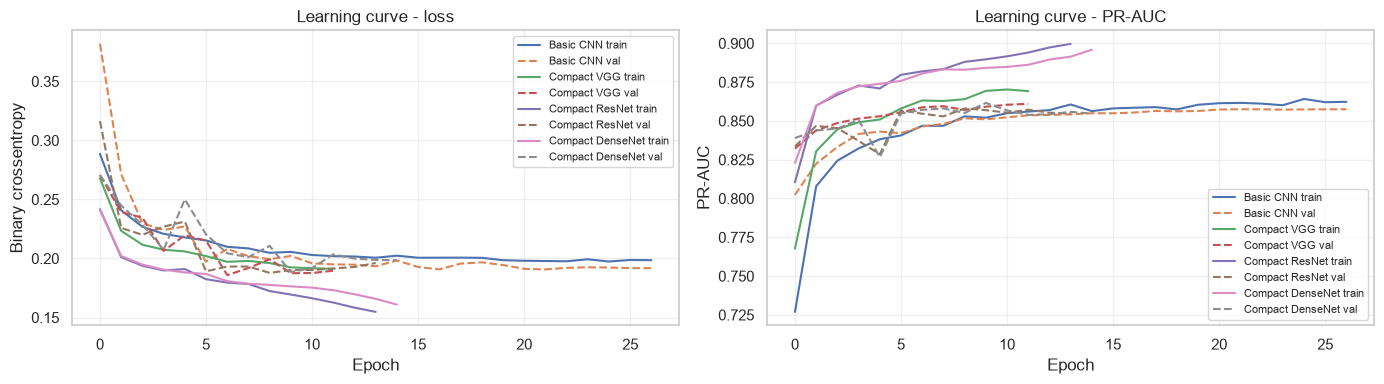

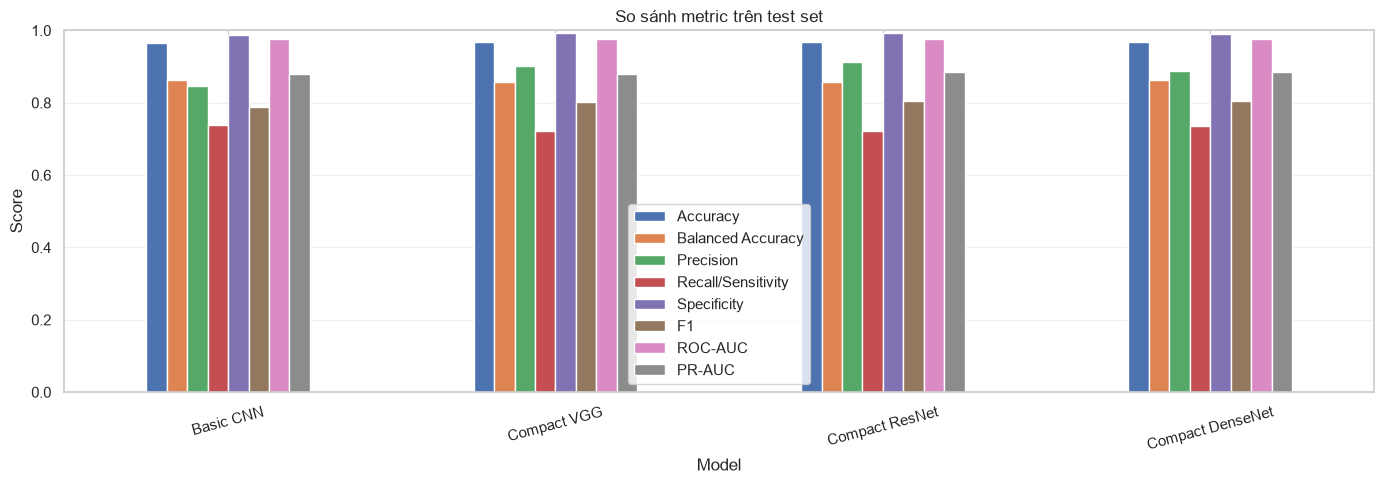

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for model_name, hist in histories.items():
    axes[0].plot(hist["loss"], label=f"{model_name} train")
    axes[0].plot(hist["val_loss"], linestyle="--", label=f"{model_name} val")
    axes[1].plot(hist["pr_auc"], label=f"{model_name} train")
    axes[1].plot(hist["val_pr_auc"], linestyle="--", label=f"{model_name} val")
axes[0].set_title("Learning curve - loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary crossentropy")
axes[1].set_title("Learning curve - PR-AUC")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("PR-AUC")
for ax in axes:
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

ax = results_df[
    ["Accuracy", "Balanced Accuracy", "Precision", "Recall/Sensitivity", "Specificity", "F1", "ROC-AUC", "PR-AUC"]
].plot(kind="bar", figsize=(14, 5), ylim=(0, 1), rot=15)
ax.set_title("So sánh metric trên test set")
ax.set_ylabel("Score")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Confusion matrix chuẩn hóa

Ma trận nhầm lẫn chuẩn hóa theo từng hàng để thấy mô hình xử lý lớp âm/dương ra sao. Với Diabetes, kích thước ma trận phải là `2x2`.

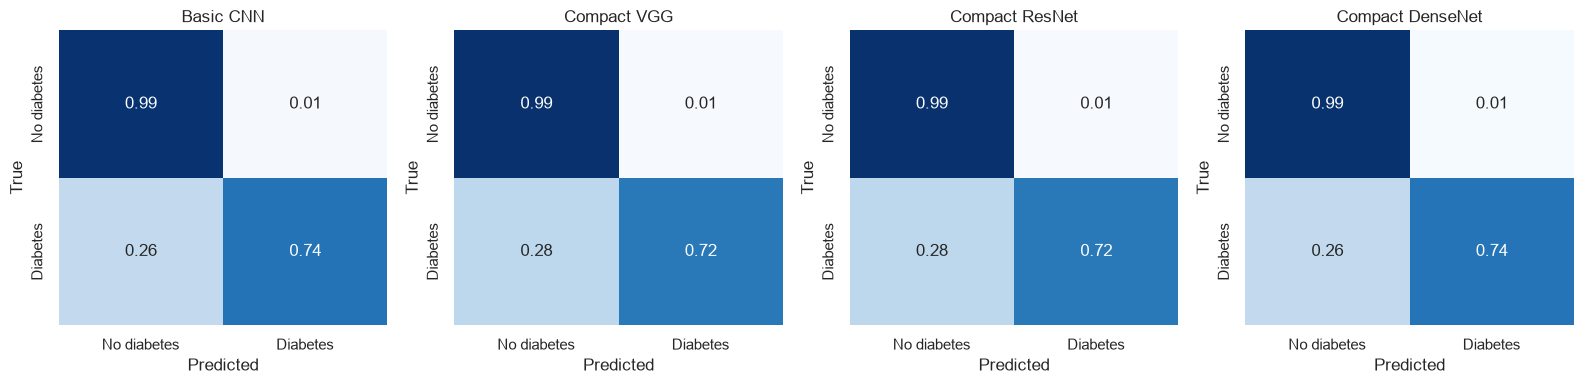

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (model_name, cm) in zip(axes, confusion_matrices.items()):
    assert cm.shape == (2, 2)
    cm_norm = cm.astype("float32") / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    sns.heatmap(
        cm_norm,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        vmin=0,
        vmax=1,
        xticklabels=["No diabetes", "Diabetes"],
        yticklabels=["No diabetes", "Diabetes"],
        cbar=False,
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.show()

## 10. Phân tích lỗi và kết luận tự sinh

Cell dưới lấy mô hình có F1 tốt nhất để xem một vài ca dự đoán sai, sau đó sinh nhận xét từ kết quả thực tế.

In [9]:
best_model_name = results_df["F1"].idxmax()
best_pred = test_predictions[best_model_name]
best_prob = test_probabilities[best_model_name]
wrong_mask = best_pred != y_test
print(f"Mô hình tốt nhất theo F1: {best_model_name}")
print(f"Số mẫu dự đoán sai: {wrong_mask.sum()} / {len(y_test)}")

error_df = test_df.loc[wrong_mask, NUMERIC_COLS + list(CATEGORICAL_LEVELS.keys()) + [TARGET_COL]].copy()
error_df["pred"] = best_pred[wrong_mask]
error_df["prob_diabetes"] = best_prob[wrong_mask]
display(error_df.sort_values("prob_diabetes", ascending=False).head(12))

best_balanced = results_df["Balanced Accuracy"].idxmax()
best_pr_auc = results_df["PR-AUC"].idxmax()
best_recall = results_df["Recall/Sensitivity"].idxmax()
print(
    f"Kết luận: {best_model_name} đạt F1 cao nhất ({results_df.loc[best_model_name, 'F1']:.4f}) "
    f"với threshold {results_df.loc[best_model_name, 'Threshold']:.3f}. "
    f"{best_balanced} mạnh nhất theo balanced accuracy, {best_pr_auc} mạnh nhất theo PR-AUC, "
    f"và {best_recall} có recall/sensitivity cao nhất. "
    "Do dữ liệu mất cân bằng, F1, PR-AUC, balanced accuracy và specificity/recall hữu ích hơn accuracy thuần. "
    "Conv1D ở đây chủ yếu giúp minh họa các kiến trúc CNN trên dữ liệu bảng; nếu tối ưu bài toán thực tế, "
    "cần so sánh thêm với mô hình chuyên cho tabular như logistic regression, random forest hoặc gradient boosting."
)

Mô hình tốt nhất theo F1: Compact ResNet
Số mẫu dự đoán sai: 442 / 14422


,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,gender,smoking_history,diabetes,pred,prob_diabetes
6322,63.0000,0,1,35.9700,6.5000,200,Male,former,0,1,0.9872
9741,58.0000,0,1,44.4900,5.7000,200,Male,No Info,0,1,0.9863
9953,67.0000,1,1,39.2200,6.6000,200,Male,never,0,1,0.9853
180,73.0000,0,1,33.2900,6.2000,200,Male,current,0,1,0.9844
4878,39.0000,1,1,66.3600,6.6000,158,Male,former,0,1,0.9734
3577,51.0000,0,1,29.7900,6.6000,200,Male,former,0,1,0.9733
2950,61.0000,0,1,35.5100,6.5000,200,Female,current,0,1,0.9731
1663,33.0000,0,1,44.4400,6.1000,140,Female,never,0,1,0.9710
8308,80.0000,1,0,22.2500,6.6000,200,Male,never,0,1,0.9708
9394,68.0000,0,1,35.0700,6.6000,140,Male,former,0,1,0.9673


Kết luận: Compact ResNet đạt F1 cao nhất (0.8060) với threshold 0.865. Compact DenseNet mạnh nhất theo balanced accuracy, Compact DenseNet mạnh nhất theo PR-AUC, và Basic CNN có recall/sensitivity cao nhất. Do dữ liệu mất cân bằng, F1, PR-AUC, balanced accuracy và specificity/recall hữu ích hơn accuracy thuần. Conv1D ở đây chủ yếu giúp minh họa các kiến trúc CNN trên dữ liệu bảng; nếu tối ưu bài toán thực tế, cần so sánh thêm với mô hình chuyên cho tabular như logistic regression, random forest hoặc gradient boosting.
